# Null and Alternative Hypothesis 

Sometimes you see something interesting in your data. A coin that looks biased.
A model that looks better. A strategy that looks profitable.

But is it **real**, or could it just be chance?

Hypothesis testing is the formal way to answer that. This notebook covers the two
hypotheses you start with, and how the decision works.

## Think of it like a courtroom

In a trial, we don't start by asking "is he guilty?"
We **assume innocence**, and then ask: is the evidence strong enough to overturn that?

Hypothesis testing works exactly the same way.

### The null hypothesis (H0) — "innocent"
The **boring** explanation. Nothing special is happening.

- the coin is fair
- the two models are equally good
- the trading strategy has no edge

### The alternative hypothesis (H1) — "guilty"
The **interesting** claim. Something really is going on.

- the coin is biased
- one model is genuinely better
- the strategy actually makes money

### The bit that surprises people
**The null is NOT what you want to prove.** It's the thing you're trying to knock down.

You *want* the alternative to be true. But you don't test it directly — you assume the
boring explanation, and then check whether your data makes that assumption look silly.

## Why start with the boring one?

Because **"nothing is happening" is a precise number, and "something is happening" isn't.**

- "the coin is fair" -> p = 0.5, exactly. We can calculate with that.
- "the coin is biased" -> biased by how much? 0.6? 0.9? No single number, nothing to compute.

So we test the precise claim and see if the data contradicts it.

It's the same trick as proof by contradiction: *assume the boring thing, show the data
would be absurd, conclude the boring thing must be wrong.*

## Two rules worth knowing

**1. You write both hypotheses BEFORE looking at the data.**
If you peek first and then decide what you were testing, you'll always "find" something.
That's cheating (it has a name: p-hacking).

**2. The alternative is usually just the opposite of the null.**
Null: "coin is fair" -> Alternative: "coin is not fair". You mostly only have to think
carefully about the null; the alternative falls out.

## Let's actually do one

We flip a coin 100 times and get **60 heads**. Suspicious?

- **H0 (null):** the coin is fair
- **H1 (alternative):** the coin is not fair

The question we ask is:

> If the coin really were fair, how often would we see something this lopsided?

To answer it, we'll simulate loads of genuinely fair coins and just count.

In [1]:
import random
random.seed(10)      # so we get the same answer every time we run it

def flip_a_fair_coin_100_times():
    heads = 0
    for i in range(100):
        result = random.choice(["heads", "tails"])
        if result == "heads":
            heads = heads + 1
    return heads

# try it once
print("one experiment gave us:", flip_a_fair_coin_100_times(), "heads")

one experiment gave us: 46 heads


In [7]:
all_results = [];

for i in range(10000):
    all_results.append(flip_a_fair_coin_100_times());

print("The first 10 results ",all_results[:10])
print();
print("notice they're NOT all 50 - fair coins wander around a bit")    

The first 10 results  [55, 53, 50, 58, 52, 53, 52, 56, 53, 54]

notice they're NOT all 50 - fair coins wander around a bit


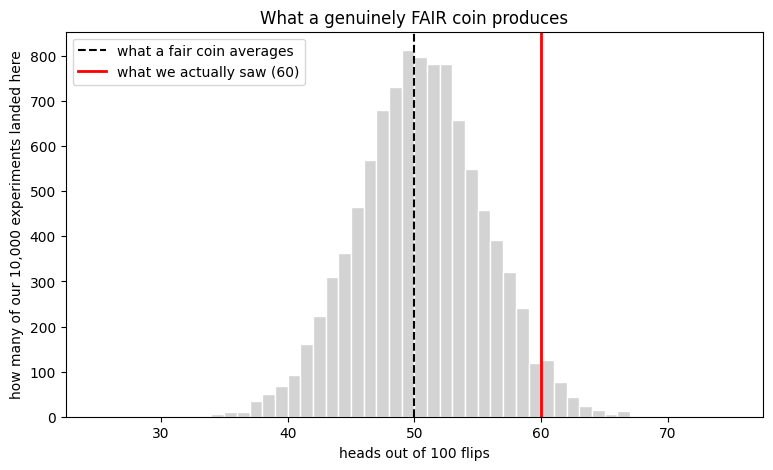

In [23]:
import matplotlib.pyplot as plt


plt.figure(figsize=(9, 5))
plt.hist(all_results, bins=range(25, 76), color="lightgrey", edgecolor="white")
plt.axvline(50, color="black", linestyle="--", label="what a fair coin averages")
plt.axvline(60, color="red", linewidth=2, label="what we actually saw (60)")
plt.xlabel("heads out of 100 flips")
plt.ylabel("how many of our 10,000 experiments landed here")
plt.title("What a genuinely FAIR coin produces")
plt.legend()
plt.show()

Look at where the red line sits. It's out in the thinner part of the histogram —
but it's **not** off in the far tail. Plenty of fair coins landed near there.

Now let's put a number on it. We count how many of our 10,000 fair coins were
**at least as lopsided** as 60.

(We count both directions — 60 heads and 40 heads are equally lopsided, just
opposite ways.)

That count, as a fraction, is called the **p-value**.

In [28]:
def p_value(observed_heads):
    how_far_from_50 = abs(observed_heads - 50)

    count_as_extreme = 0
    for result in all_results:
        if abs(result - 50) >= how_far_from_50:
            count_as_extreme = count_as_extreme + 1

    return count_as_extreme / len(all_results)


p = p_value(60)
print("p-value for 60 heads:", p)
print()
print("meaning: a genuinely fair coin gives a result this lopsided")
print(f"about {(p/100) * len(all_results)}% of the time. Uncommon - but not a miracle.")

p-value for 60 heads: 0.0582

meaning: a genuinely fair coin gives a result this lopsided
about 5.82% of the time. Uncommon - but not a miracle.


## Making the decision

We need a cutoff for "surprising enough". By convention people use **0.05**:

    p below 0.05  ->  reject the null (call it a real effect)
    p 0.05 or above ->  cannot reject (could easily be chance)

Let's see how the verdict changes as the result gets more extreme.

In [29]:
print("observed heads | p-value | decision")

for observed in [52, 55, 58, 60, 65, 70]:
    p = p_value(observed)
    if p < 0.05:
        decision = "reject the null - looks biased"
    else:
        decision = "cannot reject - could be chance"
    print("      ", observed, "      | ", round(p, 4), " |", decision)

observed heads | p-value | decision
       52       |  0.7607  | cannot reject - could be chance
       55       |  0.3636  | cannot reject - could be chance
       58       |  0.1326  | cannot reject - could be chance
       60       |  0.0582  | cannot reject - could be chance
       65       |  0.004  | reject the null - looks biased
       70       |  0.0  | reject the null - looks biased


## Two things to notice

**1. Look at the 60 row: p = 0.057.** It *just* misses the 0.05 cutoff.

If it had come out at 0.049 we'd declare the coin biased. At 0.057 we don't.
**Same evidence, opposite conclusion**, because of a line someone drew in the 1920s.

Treat p = 0.049 and p = 0.051 as basically identical evidence, because they are.

**2. "Cannot reject" is not the same as "the null is true."**

We never say "we accept the null". We say **"we fail to reject it"** — maybe the coin
really is fair, or maybe it's biased and we just didn't flip it enough times to tell.

Absence of evidence isn't evidence of absence.

## Summary

| | what it is | example |
|---|---|---|
| **null (H0)** | the boring claim — nothing is happening | the coin is fair |
| **alternative (H1)** | the interesting claim — something is happening | the coin is biased |

**How it works:** assume the null is true, then ask how surprising your data would be.
That surprise, as a number, is the **p-value**. Small p-value means your data would be
weird under the null, so the null is probably wrong.

**Things to remember:**
- the null is what you're trying to knock down, not what you want to prove
- write both hypotheses **before** looking at the data
- 0.05 is a convention, not a law of nature
- "fail to reject" never means "proven true"